## IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Loading the Dataset

In [2]:
DATA_PATH = "data/moby-bikes-historical-data-092020.csv"
df = pd.read_csv(DATA_PATH)

In [3]:
df

,HarvestTime,BikeID,Battery,BikeIdentifier,BikeTypeName,EBikeProfileID,EBikeStateID,IsEBike,IsMotor,IsSmartLock,LastGPSTime,LastRentalStart,Latitude,Longitude,SpikeID
0,2020-09-23 17:00:02,5,90.0,1,DUB-General,1,2,True,False,False,2020-09-23 17:46:16,2020-09-23 15:34:58,53.3334,-6.24431,1
1,2020-09-23 17:00:02,6,46.0,2,DUB-General,1,2,True,False,False,2020-09-23 17:44:16,2020-09-23 17:35:42,53.3414,-6.28357,2
2,2020-09-23 17:00:02,8,NaN,4,DUB-General,1,2,True,False,False,2020-09-23 11:44:01,2020-09-23 10:17:17,0.0000,0.00000,4
3,2020-09-23 17:00:02,9,68.0,5,DUB-General,1,2,True,False,False,2020-09-23 17:51:29,2020-09-22 07:48:40,53.3252,-6.25521,5
4,2020-09-23 17:00:02,12,61.0,8,DUB-General,1,2,True,False,False,2020-09-23 17:56:10,2020-09-23 17:43:14,53.3090,-6.21631,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27248,2020-09-30 23:30:03,113,77.0,109,DUB-General,1,2,True,False,False,2020-10-01 00:06:42,2020-09-30 19:34:11,53.3385,-6.24289,109
27249,2020-09-30 23:30:03,115,76.0,108,DUB-General,1,2,True,False,False,2020-10-01 00:14:14,2020-09-28 23:04:42,53.3485,-6.29516,108
27250,2020-09-30 23:30:03,116,NaN,106,DUB-General,1,2,True,False,False,2020-09-24 12:23:18,2020-09-28 09:27:52,0.0000,0.00000,106
27251,2020-09-30 23:30:03,118,87.0,32,DUB-General,1,2,True,False,False,2020-10-01 00:11:50,2020-09-30 13:04:37,53.2825,-6.14442,32


## EXPLORATORY DATA ANALYSIS

### Describing the Dataset

In [4]:
df.describe()

,BikeID,Battery,BikeIdentifier,EBikeProfileID,EBikeStateID,Latitude,Longitude,SpikeID
count,27253.000000,26576.000000,27253.000000,27253.000000,27253.000000,27253.000000,27253.000000,27253.000000
mean,60.219279,61.997554,56.592045,1.049536,2.013210,51.626444,-6.048307,56.592045
std,33.015160,22.071490,33.282319,0.382308,0.233296,9.397413,1.102131,33.282319
min,5.000000,-9.000000,1.000000,1.000000,1.000000,0.000000,-6.370620,1.000000
25%,33.000000,45.000000,28.000000,1.000000,2.000000,53.312000,-6.274750,28.000000
50%,61.000000,68.000000,55.000000,1.000000,2.000000,53.339800,-6.257520,55.000000
75%,87.000000,80.000000,83.000000,1.000000,2.000000,53.354400,-6.230890,83.000000
max,124.000000,98.000000,120.000000,4.000000,5.000000,53.393400,0.000000,120.000000


### Shape and Info

In [5]:
print("\nDataset Shape:\n", df.shape)


Dataset Shape:
 (27253, 15)


In [6]:
print("\nColumns Info:\n")
print(df.info())


Columns Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27253 entries, 0 to 27252
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   HarvestTime      27253 non-null  object 
 1   BikeID           27253 non-null  int64  
 2   Battery          26576 non-null  float64
 3   BikeIdentifier   27253 non-null  int64  
 4   BikeTypeName     27253 non-null  object 
 5   EBikeProfileID   27253 non-null  int64  
 6   EBikeStateID     27253 non-null  int64  
 7   IsEBike          27253 non-null  bool   
 8   IsMotor          27253 non-null  bool   
 9   IsSmartLock      27253 non-null  bool   
 10  LastGPSTime      27253 non-null  object 
 11  LastRentalStart  27253 non-null  object 
 12  Latitude         27253 non-null  float64
 13  Longitude        27253 non-null  float64
 14  SpikeID          27253 non-null  int64  
dtypes: bool(3), float64(3), int64(5), object(4)
memory usage: 2.6+ MB
None


### Identifying Missing Values

In [7]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 HarvestTime          0
BikeID               0
Battery            677
BikeIdentifier       0
BikeTypeName         0
EBikeProfileID       0
EBikeStateID         0
IsEBike              0
IsMotor              0
IsSmartLock          0
LastGPSTime          0
LastRentalStart      0
Latitude             0
Longitude            0
SpikeID              0
dtype: int64


### Battery column has missing values — inspecting unique values

In [8]:
df['Battery'].unique()

array([90., 46., nan, 68., 61., 77., 41., 63., 35., 67., 66., 47., 82.,
       58., 62., 76., 85., 38., 80., 44., 93., 65., 97., 96., 37., 72.,
       70., 71., 57., 81., 92., 86., 75., 48., 91., 87., 60., 83., 74.,
       73., 98., 56., 84., 64., 53., 94., 45., 36., 34., 52., 55., 50.,
       33., 42., 78., 54., 88., 43., 40., 32., 30., 28., 95., 31., 27.,
       26., 25., 24., 23., 51., 21., 18., 15.,  4., -3., 14., 16., 12.,
       11., 10.,  7.,  6.,  5., 13., -4.,  2., 22., -8., -2.,  1., 20.,
       -6.,  8., 17.,  3.,  0., -5., -9., -7.])

## Handling Missing Values & Cleaning

In [9]:
df['Battery'] = df['Battery'].fillna(df['Battery'].median())
df['HarvestTime'] = pd.to_datetime(df['HarvestTime'])
df = df[(df['Latitude'] != 0) | (df['Longitude'] != 0)]
drop_columns = ['BikeID', 'BikeIdentifier', 'SpikeID', 'LastGPSTime', 'LastRentalStart']
df = df.drop(columns=drop_columns)
negative_battery_count = (df['Battery'] < 0).sum()
print(f"Number of rows with negative Battery values: {negative_battery_count}")
df_cleaned = df[df['Battery'] >= 0].copy()
print(f"Number of rows after removing negatives: {df_cleaned.shape[0]}")
print("\nSummary statistics:")
print(df_cleaned.describe())
print("\nBikeTypeName distribution:")
print(df_cleaned['BikeTypeName'].value_counts())

Number of rows with negative Battery values: 179
Number of rows after removing negatives: 26200

Summary statistics:
                         HarvestTime       Battery  EBikeProfileID  \
count                          26200  26200.000000    26200.000000   
mean   2020-09-27 08:31:52.839274752     62.396031        1.046832   
min              2020-09-23 17:00:02      0.000000        1.000000   
25%              2020-09-25 11:30:01     45.000000        1.000000   
50%              2020-09-27 07:00:04     68.000000        1.000000   
75%              2020-09-29 06:00:03     80.000000        1.000000   
max              2020-09-30 23:30:03     98.000000        4.000000   
std                              NaN     21.415217        0.371898   

       EBikeStateID      Latitude     Longitude  
count  26200.000000  26200.000000  26200.000000  
mean       2.015496     53.336973     -6.248684  
min        1.000000     53.279800     -6.370620  
25%        2.000000     53.322900     -6.274760  
50

### Cleaned Dataset Overview

In [10]:
df_cleaned.shape

(26200, 10)

In [11]:
df_cleaned.describe()

,HarvestTime,Battery,EBikeProfileID,EBikeStateID,Latitude,Longitude
count,26200,26200.000000,26200.000000,26200.000000,26200.000000,26200.000000
mean,2020-09-27 08:31:52.839274752,62.396031,1.046832,2.015496,53.336973,-6.248684
min,2020-09-23 17:00:02,0.000000,1.000000,1.000000,53.279800,-6.370620
25%,2020-09-25 11:30:01,45.000000,1.000000,2.000000,53.322900,-6.274760
50%,2020-09-27 07:00:04,68.000000,1.000000,2.000000,53.341300,-6.257580
75%,2020-09-29 06:00:03,80.000000,1.000000,2.000000,53.355700,-6.231800
max,2020-09-30 23:30:03,98.000000,4.000000,5.000000,53.393400,-6.113820
std,NaN,21.415217,0.371898,0.234094,0.025914,0.051665


In [12]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26200 entries, 0 to 27252
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   HarvestTime     26200 non-null  datetime64[ns]
 1   Battery         26200 non-null  float64       
 2   BikeTypeName    26200 non-null  object        
 3   EBikeProfileID  26200 non-null  int64         
 4   EBikeStateID    26200 non-null  int64         
 5   IsEBike         26200 non-null  bool          
 6   IsMotor         26200 non-null  bool          
 7   IsSmartLock     26200 non-null  bool          
 8   Latitude        26200 non-null  float64       
 9   Longitude       26200 non-null  float64       
dtypes: bool(3), datetime64[ns](1), float64(3), int64(2), object(1)
memory usage: 1.7+ MB


### Feature Engineering: Time-based Features from HarvestTime

In [13]:
df_cleaned['Hour'] = df_cleaned['HarvestTime'].dt.hour
df_cleaned['DayOfWeek'] = df_cleaned['HarvestTime'].dt.dayofweek  # 0=Mon, 6=Sun
print('Hour range:', df_cleaned['Hour'].min(), '-', df_cleaned['Hour'].max())
print('DayOfWeek range:', df_cleaned['DayOfWeek'].min(), '-', df_cleaned['DayOfWeek'].max())

Hour range: 0 - 23
DayOfWeek range: 0 - 6


### Battery Level Categorisation

In [14]:
df_cleaned['BatteryLevel'] = pd.cut(
    df_cleaned['Battery'], bins=[0, 30, 60, 100], labels=['Low', 'Medium', 'High']
)
print(df_cleaned['BatteryLevel'].value_counts())

BatteryLevel
High      16439
Medium     7453
Low        2289
Name: count, dtype: int64


## Visualisations

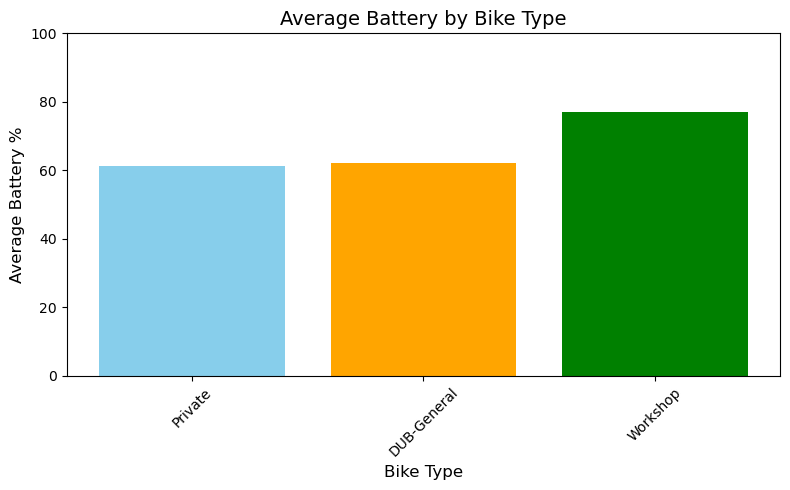

In [15]:
mean_battery = df_cleaned.groupby('BikeTypeName')['Battery'].mean().sort_values()
plt.figure(figsize=(8, 5))
plt.bar(mean_battery.index, mean_battery.values, color=['skyblue', 'orange', 'green'])
plt.title('Average Battery by Bike Type', fontsize=14)
plt.xlabel('Bike Type', fontsize=12)
plt.ylabel('Average Battery %', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("avg_battery_by_bike_type.png", dpi=150, bbox_inches='tight')
plt.show()

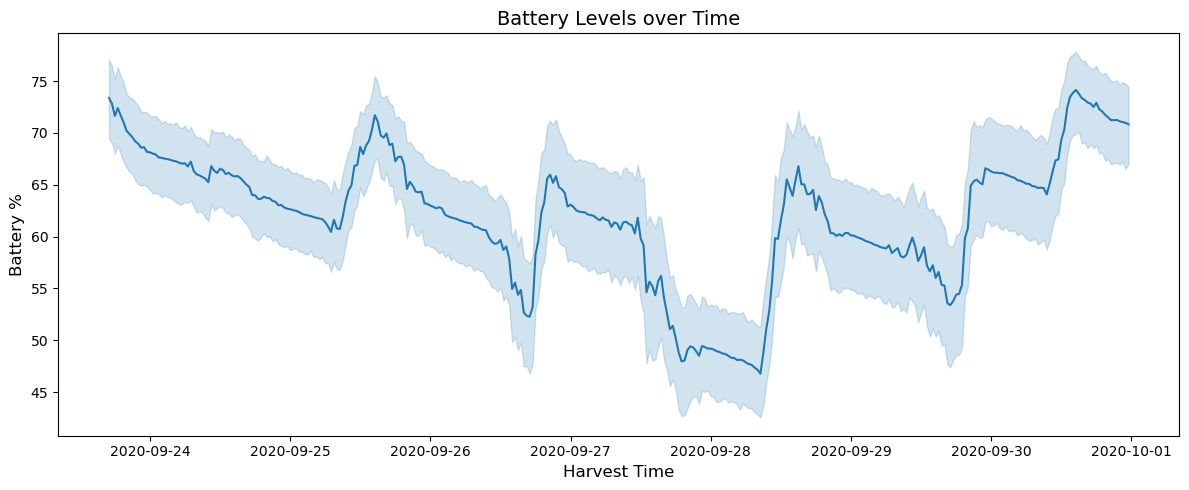

In [16]:
plt.figure(figsize=(12, 5))
sns.lineplot(x='HarvestTime', y='Battery', data=df_cleaned)
plt.title('Battery Levels over Time', fontsize=14)
plt.xlabel('Harvest Time', fontsize=12)
plt.ylabel('Battery %', fontsize=12)
plt.tight_layout()
plt.savefig("battery_over_time.png", dpi=150, bbox_inches='tight')
plt.show()

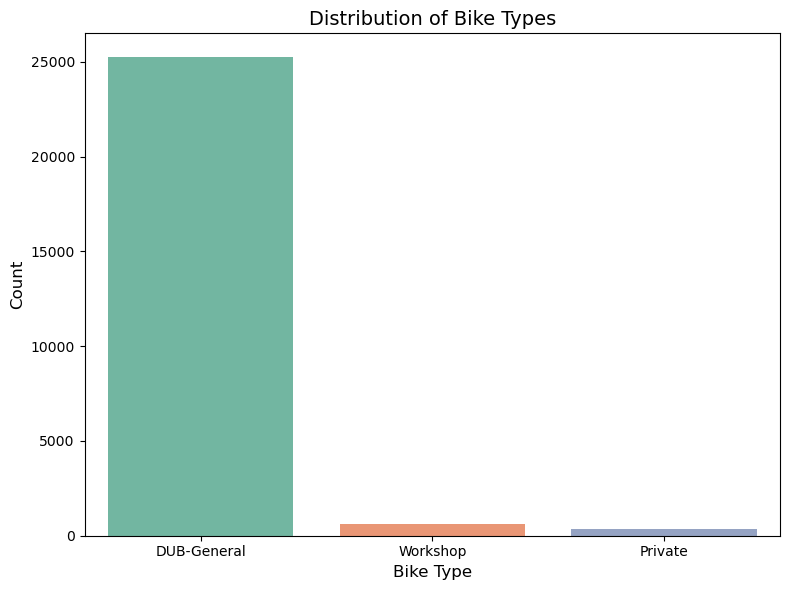

In [17]:
plt.figure(figsize=(8, 6))
sns.countplot(x='BikeTypeName', hue='BikeTypeName', data=df_cleaned,
              palette='Set2', legend=False)
plt.title('Distribution of Bike Types', fontsize=14)
plt.xlabel('Bike Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig("bike_type_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

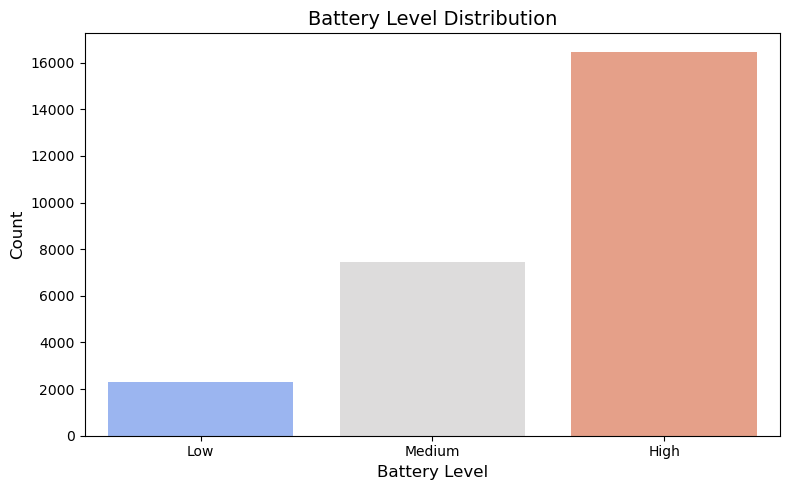

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(x='BatteryLevel', hue='BatteryLevel', data=df_cleaned,
              palette='coolwarm', order=['Low', 'Medium', 'High'], legend=False)
plt.title('Battery Level Distribution', fontsize=14)
plt.xlabel('Battery Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig("battery_level_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

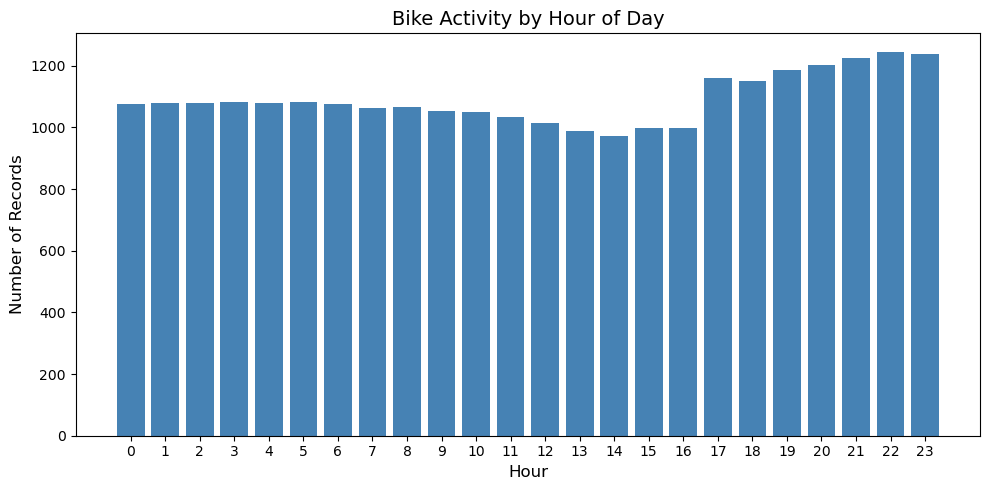

In [19]:
hourly_counts = df_cleaned.groupby('Hour').size()
plt.figure(figsize=(10, 5))
plt.bar(hourly_counts.index, hourly_counts.values, color='steelblue')
plt.title('Bike Activity by Hour of Day', fontsize=14)
plt.xlabel('Hour', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig("bike_activity_by_hour.png", dpi=150, bbox_inches='tight')
plt.show()

## K-Means Clustering — Elbow Method to Choose k

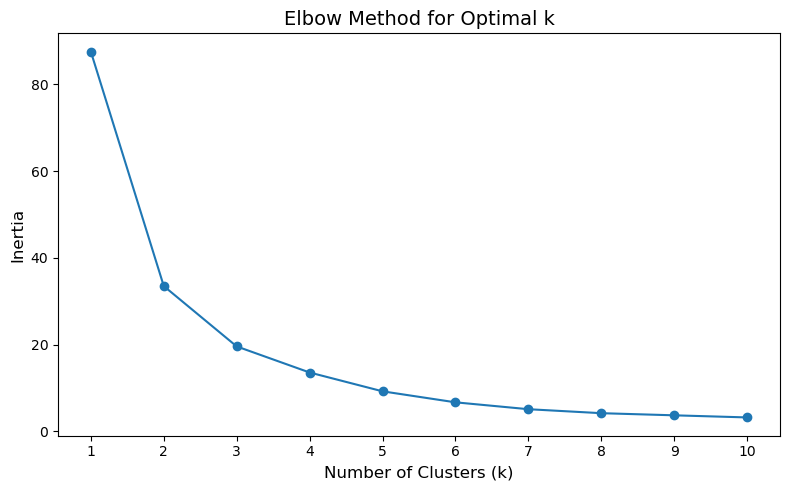

In [20]:
# Work on a copy so df_cleaned stays clean for modelling
df_cluster = df_cleaned.copy()
coords = df_cluster[['Latitude', 'Longitude']]
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(coords)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method for Optimal k', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.xticks(k_range)
plt.tight_layout()
plt.savefig("elbow_method.png", dpi=150, bbox_inches='tight')
plt.show()

### K-Means with k=6 (chosen from elbow plot)

In [21]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(coords)
print(df_cluster['Cluster'].value_counts())

Cluster
0    7642
2    5996
4    5855
3    2991
5    1894
1    1822
Name: count, dtype: int64


### Clustering Visualisation

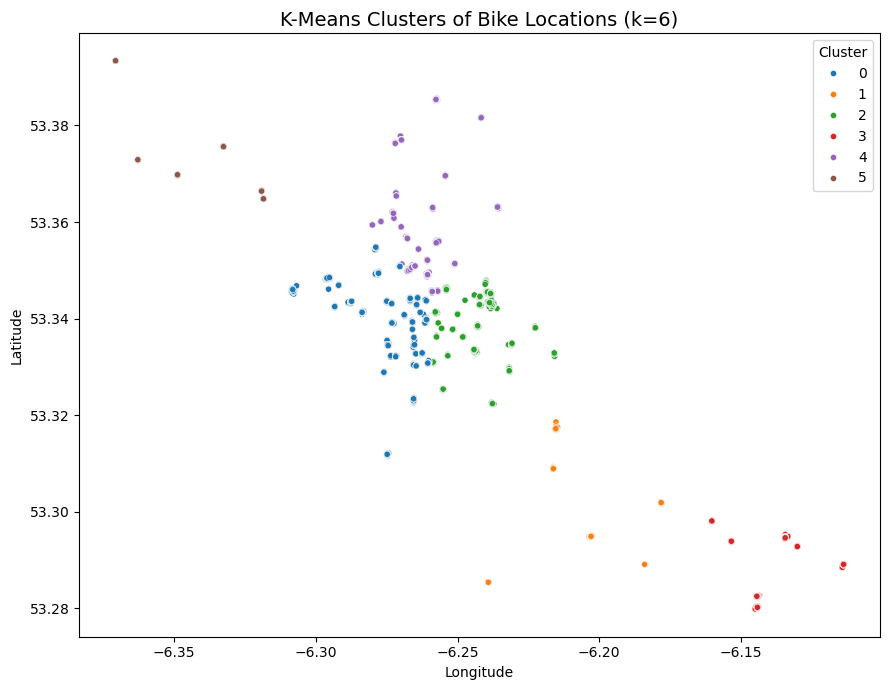

In [22]:
plt.figure(figsize=(9, 7))
sns.scatterplot(
    x=df_cluster['Longitude'],
    y=df_cluster['Latitude'],
    hue=df_cluster['Cluster'],
    palette='tab10',
    s=20
)
plt.title("K-Means Clusters of Bike Locations (k=6)", fontsize=14)
plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=150, bbox_inches='tight')
plt.show()

## MODEL CREATION

In [23]:
# Include engineered time features in the model
numeric_features = ['Battery', 'Latitude', 'Longitude', 'EBikeProfileID', 'EBikeStateID', 'Hour', 'DayOfWeek']
bool_features = ['IsEBike', 'IsMotor', 'IsSmartLock']
X = df_cleaned[numeric_features + bool_features]
y = df_cleaned['BikeTypeName']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

def build_pipeline(model, numeric_feats, bool_feats):
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numeric_feats),
        ('bool', 'passthrough', bool_feats)
    ])
    return Pipeline([
        ('pre', preprocessor),
        ('model', model)
    ])

### Baseline Model (Dummy Classifier)

In [24]:
dummy = DummyClassifier(strategy='most_frequent')
dummy_scores = cross_val_score(dummy, X_train, y_train, cv=5, scoring='accuracy')
dummy.fit(X_train, y_train)
dummy_test_acc = dummy.score(X_test, y_test)
print(f"Dummy Baseline CV Accuracy: {dummy_scores.mean():.4f}")
print(f"Dummy Baseline Test Accuracy: {dummy_test_acc:.4f}")

Dummy Baseline CV Accuracy: 0.9635
Dummy Baseline Test Accuracy: 0.9635


### Logistic Regression

In [25]:
lr_pipeline = build_pipeline(LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='auto'), numeric_features, bool_features)
lr_cv = cross_val_score(lr_pipeline, X_train, y_train, cv=StratifiedKFold(10), scoring='accuracy')
lr_pipeline.fit(X_train, y_train)
original_lr_acc = lr_pipeline.score(X_test, y_test)
print(f"Logistic Regression 10-fold CV Accuracy: {lr_cv.mean():.4f}")
print(f"Logistic Regression Test Set Accuracy: {original_lr_acc:.4f}")

c:\Users\SRINI\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\SRINI\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\SRINI\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\SRINI\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in versio

Logistic Regression 10-fold CV Accuracy: 0.9635
Logistic Regression Test Set Accuracy: 0.9635


c:\Users\SRINI\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Random Forest Classifier

In [26]:
rf_pipeline = build_pipeline(RandomForestClassifier(n_estimators=100, random_state=42), numeric_features, bool_features)
rf_cv = cross_val_score(rf_pipeline, X_train, y_train, cv=StratifiedKFold(10), scoring='accuracy')
rf_pipeline.fit(X_train, y_train)
original_rf_acc = rf_pipeline.score(X_test, y_test)
print(f"Random Forest 10-fold CV Accuracy: {rf_cv.mean():.4f}")
print(f"Random Forest Test Set Accuracy: {original_rf_acc:.4f}")

Random Forest 10-fold CV Accuracy: 0.9988
Random Forest Test Set Accuracy: 0.9992


### MLP Neural Network

In [27]:
mlp_pipeline = build_pipeline(MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42), numeric_features, bool_features)
mlp_cv = cross_val_score(mlp_pipeline, X_train, y_train, cv=StratifiedKFold(10), scoring='accuracy')
mlp_pipeline.fit(X_train, y_train)
original_mlp_acc = mlp_pipeline.score(X_test, y_test)
print(f"MLP Neural Network 10-fold CV Accuracy: {mlp_cv.mean():.4f}")
print(f"MLP Neural Network Test Set Accuracy: {original_mlp_acc:.4f}")

MLP Neural Network 10-fold CV Accuracy: 0.9985
MLP Neural Network Test Set Accuracy: 0.9987


## Feature Selection via Random Forest Importance

In [28]:
# Random Forest does not require feature scaling, so we fit directly
# on unscaled X_train for feature importance scoring.
rf_fs = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fs.fit(X_train, y_train)

feature_importance_df = pd.DataFrame({
    'Feature': X.columns.tolist(),
    'Importance': rf_fs.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_features_rf = feature_importance_df['Feature'][:5].tolist()
print("Top 5 Features:", top_features_rf)
print()
print(feature_importance_df.to_string(index=False))

Top 5 Features: ['Latitude', 'Longitude', 'Battery', 'DayOfWeek', 'Hour']

       Feature  Importance
      Latitude    0.465998
     Longitude    0.311540
       Battery    0.157346
     DayOfWeek    0.038796
          Hour    0.022808
  EBikeStateID    0.002817
EBikeProfileID    0.000695
       IsEBike    0.000000
       IsMotor    0.000000
   IsSmartLock    0.000000


### Models Re-trained on Top 5 Selected Features

In [29]:
numeric_top = [f for f in top_features_rf if f in numeric_features]
bool_top = [f for f in top_features_rf if f in bool_features]

#### Logistic Regression on Selected Features

In [30]:
lr_pipeline_top = build_pipeline(LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='auto'), numeric_top, bool_top)
lr_pipeline_top.fit(X_train[top_features_rf], y_train)
lr_acc_selected = lr_pipeline_top.score(X_test[top_features_rf], y_test)
print(f"Logistic Regression (Top Features) Test Accuracy: {lr_acc_selected:.4f}")

Logistic Regression (Top Features) Test Accuracy: 0.9635


c:\Users\SRINI\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


#### Random Forest on Selected Features

In [31]:
rf_pipeline_top = build_pipeline(RandomForestClassifier(n_estimators=100, random_state=42), numeric_top, bool_top)
rf_pipeline_top.fit(X_train[top_features_rf], y_train)
rf_acc_selected = rf_pipeline_top.score(X_test[top_features_rf], y_test)
print(f"Random Forest (Top Features) Test Accuracy: {rf_acc_selected:.4f}")

Random Forest (Top Features) Test Accuracy: 0.9992


#### MLP Neural Network on Selected Features

In [32]:
mlp_pipeline_top = build_pipeline(MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42), numeric_top, bool_top)
mlp_pipeline_top.fit(X_train[top_features_rf], y_train)
mlp_acc_selected = mlp_pipeline_top.score(X_test[top_features_rf], y_test)
print(f"MLP Neural Network (Top Features) Test Accuracy: {mlp_acc_selected:.4f}")

MLP Neural Network (Top Features) Test Accuracy: 0.9977


## Comparing All Models

In [33]:
comparison_df = pd.DataFrame({
    'Model': ['Dummy Baseline', 'Logistic Regression', 'Random Forest', 'MLP Neural Network'],
    'Cross-Validation Accuracy': [dummy_scores.mean(), lr_cv.mean(), rf_cv.mean(), mlp_cv.mean()],
    'Test Accuracy (Full Features)': [dummy_test_acc, original_lr_acc, original_rf_acc, original_mlp_acc],
    'Test Accuracy (Selected Features)': [dummy_test_acc, lr_acc_selected, rf_acc_selected, mlp_acc_selected]
})
comparison_df

,Model,Cross-Validation Accuracy,Test Accuracy (Full Features),Test Accuracy (Selected Features)
0,Dummy Baseline,0.963502,0.963550,0.963550
1,Logistic Regression,0.963502,0.963550,0.963550
2,Random Forest,0.998807,0.999237,0.999237
3,MLP Neural Network,0.998473,0.998664,0.997710


### Model Accuracy Comparison Chart

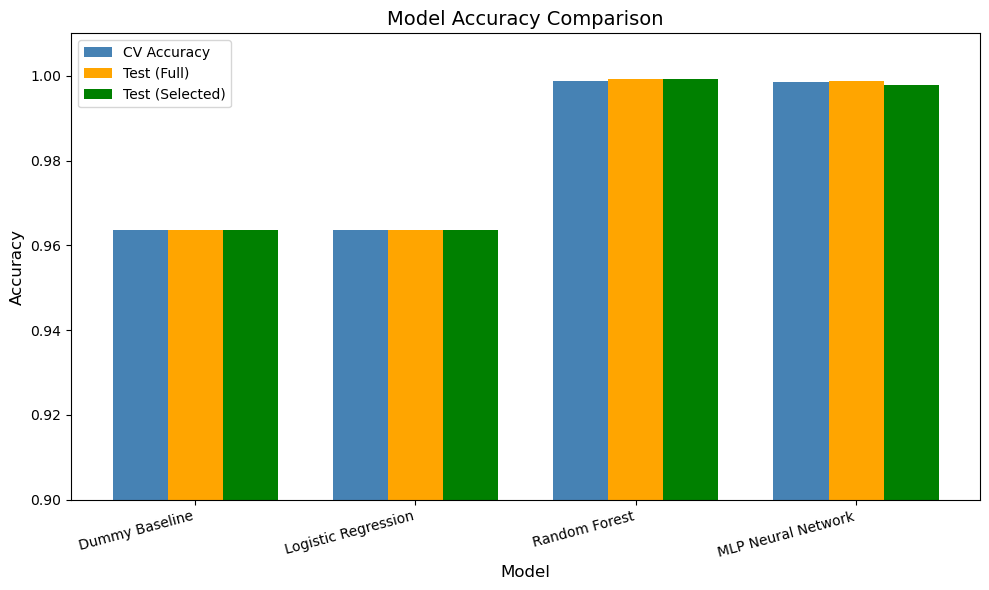

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.25
ax.bar(x - width, comparison_df['Cross-Validation Accuracy'],      width, label='CV Accuracy',      color='steelblue')
ax.bar(x,          comparison_df['Test Accuracy (Full Features)'],  width, label='Test (Full)',       color='orange')
ax.bar(x + width, comparison_df['Test Accuracy (Selected Features)'], width, label='Test (Selected)', color='green')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Accuracy Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.set_ylim(0.9, 1.01)
ax.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## Best Model: Random Forest — Classification Report & Confusion Matrix

In [35]:
y_pred_rf = rf_pipeline.predict(X_test)
print("Classification Report (Random Forest — Full Features):")
print(classification_report(y_test, y_pred_rf))

Classification Report (Random Forest — Full Features):
              precision    recall  f1-score   support

 DUB-General       1.00      1.00      1.00      5049
     Private       0.99      0.96      0.97        70
    Workshop       1.00      1.00      1.00       121

    accuracy                           1.00      5240
   macro avg       0.99      0.99      0.99      5240
weighted avg       1.00      1.00      1.00      5240



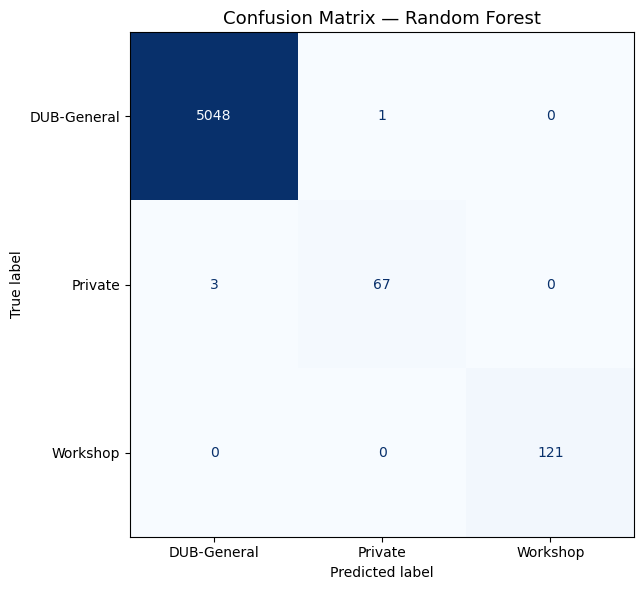

In [36]:
cm = confusion_matrix(y_test, y_pred_rf, labels=rf_pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_pipeline.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest', fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=150, bbox_inches='tight')
plt.show()

## Permutation Importance — Random Forest

In [37]:
# A separate RF (200 estimators, full pipeline) is used here for permutation
# importance. More estimators improve stability across repeated shuffles.
# This is distinct from the 100-estimator pipeline used for classification above.
preprocessor_pi = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('bool', 'passthrough', bool_features)
])

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor_pi),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)

result = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

perm_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

perm_importances

,Feature,Importance
1,Latitude,0.035496
2,Longitude,0.029943
0,Battery,0.023149
6,DayOfWeek,0.003569
5,Hour,0.000210
3,EBikeProfileID,0.000038
4,EBikeStateID,0.000000
7,IsEBike,0.000000
8,IsMotor,0.000000
9,IsSmartLock,0.000000


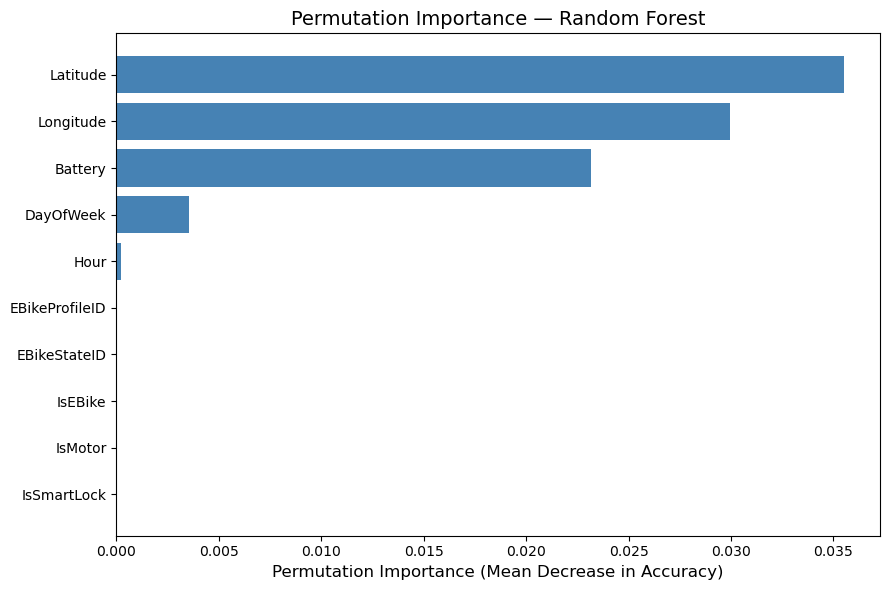

In [38]:
plt.figure(figsize=(9, 6))
plt.barh(perm_importances['Feature'], perm_importances['Importance'], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance (Mean Decrease in Accuracy)", fontsize=12)
plt.title("Permutation Importance — Random Forest", fontsize=14)
plt.tight_layout()
plt.savefig("permutation_importance.png", dpi=150, bbox_inches='tight')
plt.show()